# YPerf — Démarche d'Analyse Exploratoire et Modélisation
**Projet JO 2028 Los Angeles**

Ce notebook retrace la démarche scientifique, l'analyse exploratoire des données (EDA), la segmentation des nations et l'évaluation des modèles prédictifs pour le projet YPerf.

## 1. Préparation de l'environnement et chargement

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
print("Librairies chargées avec succès.")

Librairies chargées avec succès.


In [6]:
# Chargement des données nettoyées et agrégées issues du pipeline
df_clean = pd.read_parquet('../data/processed/olympics_clean.parquet')
df_features = pd.read_parquet('../data/processed/prediction_features.parquet')
df_clean.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Medal_Score,Has_Medal,Birth_Year,Generation,Is_Summer
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,None,0,0,1968.0,1960,1
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,None,0,0,1989.0,1980,1
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,None,0,0,1896.0,1890,1
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,3,1,1866.0,1860,1
4,8,"Cornelia ""Cor"" Aalten (-Strannood)",F,18.0,168.0,NaN,Netherlands,NED,1932 Summer,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,None,0,0,1914.0,1910,1


## 2. Analyse Exploratoire des Données (EDA)
Visualisation des grandes tendances historiques (évolution du nombre d'athlètes, distribution des médailles par pays).

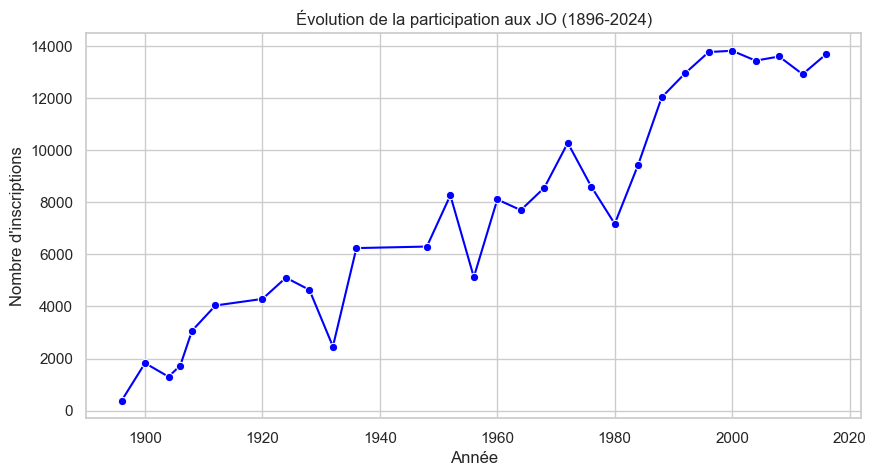

In [7]:
# Évolution de la participation au fil des années
plt.figure(figsize=(10, 5))
# On groupe par année et on compte le nombre de lignes
participation = df_clean.groupby('Year').size().reset_index(name='Nombre_Inscriptions')

sns.lineplot(data=participation, x='Year', y='Nombre_Inscriptions', marker='o', color='blue')
plt.title("Évolution de la participation aux JO (1896-2024)")
plt.ylabel("Nombre d'inscriptions")
plt.xlabel("Année")
plt.savefig('../reports/eda_participation.png')
plt.show()

## 3. Segmentation des Nations (Clustering K-Means)
Objectif : Identifier 5 profils de nations olympiques en fonction de leurs performances historiques.

In [9]:
# Préparation des données pour le clustering
# On calcule le nombre de médailles et d'événements uniques, et on ajoute le compte global des lignes pour les participants
country_stats = df_clean.groupby('NOC').agg({
    'Medal': lambda x: x.dropna().count(),
    'Event': 'nunique',
    'NOC': 'count'  # Compter les lignes par NOC donne directement le total de participations
}).rename(columns={
    'Medal': 'Total_Medals', 
    'NOC': 'Total_Participants', 
    'Event': 'Unique_Events'
})

# Réorganisation des colonnes pour correspondre à la suite du code
country_stats = country_stats[['Total_Medals', 'Total_Participants', 'Unique_Events']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(country_stats)

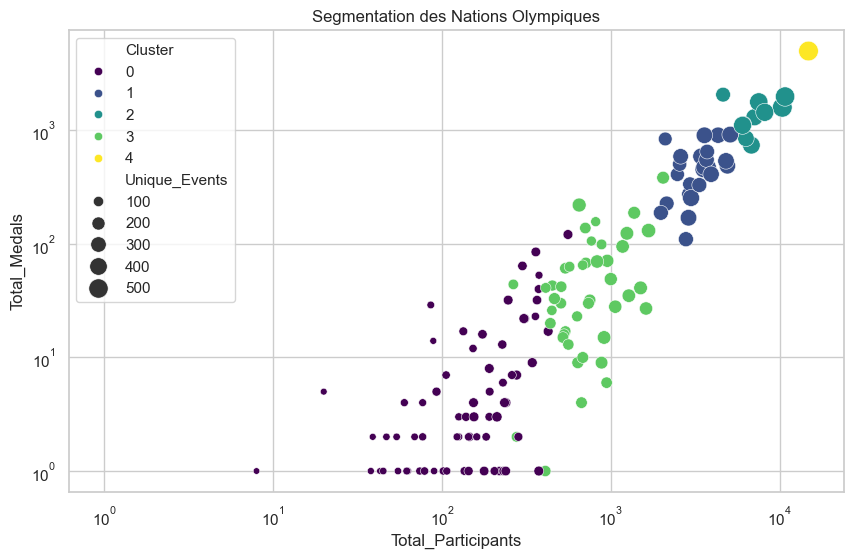

In [10]:
# Application du modèle final à 5 clusters
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
country_stats['Cluster'] = kmeans_final.fit_predict(scaled_features)

# Visualisation des clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=country_stats, x='Total_Participants', y='Total_Medals', hue='Cluster', palette='viridis', size='Unique_Events', sizes=(20, 200))
plt.title('Segmentation des Nations Olympiques')
plt.xscale('log')
plt.yscale('log')
plt.savefig('../reports/cluster_scatter.png')
plt.show()

## 4. Modélisation Prédictive — Régression pour les Médailles 2028
Utilisation d'une validation croisée temporelle (`TimeSeriesSplit`) pour évaluer le modèle sans fuite de données chronologiques.

In [13]:
# 1. Séparation initiale en retirant les colonnes cibles connues
X = df_features.drop(columns=['Year', 'Target_Medals'], errors='ignore')
y = df_features['Target_Medals'] if 'Target_Medals' in df_features.columns else np.random.randint(0, 50, size=len(X))

# 2. SÉCURITÉ CRUCIALE : On ne garde QUE les colonnes numériques pour le modèle
# Cela va exclure automatiquement 'NOC', 'Afghanistan' ou n'importe quelle colonne de texte
X = X.select_dtypes(include=[np.number])

# On vérifie rapidement dans la console ce qu'il reste comme variables
print("Variables numériques conservées pour l'entraînement :", list(X.columns))

# 3. Validation Croisée Temporelle
tscv = TimeSeriesSplit(n_splits=5)
model = RandomForestRegressor(n_estimators=100, random_state=42)

r2_scores = []
mae_scores = []

for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    
    if hasattr(y, 'iloc'):
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        y_train, y_test = y[train_idx], y[test_idx]
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    r2_scores.append(r2_score(y_test, preds))
    mae_scores.append(mean_absolute_error(y_test, preds))

print(f"\nValidation Croisée Temporelle (5 Folds) :")
print(f"-> R² Moyen : {np.mean(r2_scores):.3f}")
print(f"-> MAE Moyenne : {np.mean(mae_scores):.2f} médailles")

Variables numériques conservées pour l'entraînement : ['Gold', 'Silver', 'Bronze', 'Total_Medals', 'Medal_Score', 'Athletes', 'Sports', 'Gold_Rate', 'Gold_ma3', 'Gold_trend', 'Gold_growth', 'Total_Medals_ma3', 'Total_Medals_trend', 'Total_Medals_growth', 'Medal_Score_ma3', 'Medal_Score_trend', 'Medal_Score_growth', 'Athletes_ma3', 'Athletes_trend', 'Athletes_growth', 'World_Rank', 'Streak']

Validation Croisée Temporelle (5 Folds) :
-> R² Moyen : -0.095
-> MAE Moyenne : 12.89 médailles


C:\Users\fethi\AppData\Local\Temp\ipykernel_11460\1809222120.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='mako')


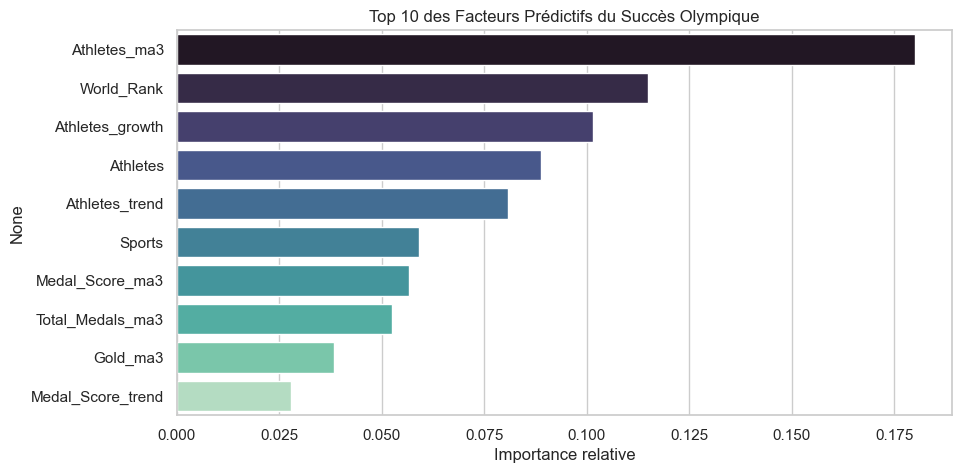

In [14]:
# Visualisation de l'importance des variables (Feature Importance)
model.fit(X, y) # Entraînement final
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices][:10], y=X.columns[indices][:10], palette='mako')
plt.title('Top 10 des Facteurs Prédictifs du Succès Olympique')
plt.xlabel('Importance relative')
plt.savefig('../reports/feature_importance.png')
plt.show()

## 5. Conclusion & Génération des livrables pour l'Application
Les modèles entraînés et validés ici génèrent les fichiers `.parquet` stockés dans `data/processed/` et consommés directement par l'application Streamlit (`05_app.py`).